# ブートストラップSHAP: JEPX電力価格（実データ）

電力スポット価格は**価格スパイク**という本物の外れ値を持つ回帰問題。
合成データで裏取りした手法を適用し、「高重要度だが低信頼（高CV）」な特徴を炙り出す。

※ 目的変数の変換・派生列（`target_log1p` 等）は**リーク**なので特徴から除外する。
※ 予測精度が目的ではないため特徴量成形は最低限。

In [1]:
import numpy as np, pandas as pd, shap, matplotlib.pyplot as plt
from xgboost import XGBRegressor
from scipy import stats
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.grid":True,
                     "grid.alpha":.3,"axes.axisbelow":True})
B, SEED, EXPL = 40, 42, 8000
LEAK=["target_log1p","target_arsinh","target_diff_1d","target_diff_7d",
      "target_dev_prev_day","target_dev_prev_week","trend_30d_mean"]

/home/kohei/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_parquet("../06.JEPX_estimation/data/jepx_tokyo_features.parquet")
y=df["target"].to_numpy()
X=df.drop(columns=["target"]+LEAK).copy()
X=X.fillna(X.median(numeric_only=True))
cols=list(X.columns); n=len(X)
print("X:", X.shape, "| target mean %.1f max %.1f" % (y.mean(), y.max()))
cols

X: (107472, 30) | target mean 14.8 max 252.0


['hour',
 'minute',
 'dayofweek',
 'month',
 'day',
 'is_weekend',
 'is_holiday',
 'is_dayoff',
 'temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'shortwave_radiation',
 'precipitation',
 'tepco_demand',
 'tepco_solar',
 'tepco_wind',
 'net_demand',
 'pv_ratio',
 'lag_1d_same_slot',
 'lag_7d_same_slot',
 'prev_day_mean',
 'prev_day_max',
 'prev_day_min',
 'prev_day_std',
 'prev_week_same_dow_mean',
 'prev_week_same_dow_max',
 'prev_week_same_dow_min',
 'prev_week_same_dow_std',
 'prev_day_band_peak',
 'prev_day_band_early']

In [3]:
def fit(X,y,seed):
    return XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=seed, n_jobs=8).fit(X,y)
def abs_shap(m,X):
    return np.abs(shap.TreeExplainer(m).shap_values(X))

### 標準の単発SHAP（説明は固定の8000サンプル）

In [4]:
rng=np.random.default_rng(SEED)
eidx=rng.choice(n, EXPL, replace=False)
m0=fit(X,y,0); A0=abs_shap(m0, X.iloc[eidx])
std =pd.Series(A0.mean(0), index=cols)
med =pd.Series(np.median(A0,0), index=cols)
std.sort_values(ascending=False).head(12).round(3)

lag_1d_same_slot           3.129
net_demand                 1.634
prev_day_band_early        1.261
lag_7d_same_slot           0.958
prev_day_mean              0.649
pv_ratio                   0.599
month                      0.449
prev_day_band_peak         0.337
dayofweek                  0.331
prev_day_max               0.309
tepco_demand               0.305
prev_week_same_dow_mean    0.150
dtype: float32

### ブートストラップSHAP（B=40, 毎回再学習）

107k行を毎回復元抽出→再学習するため数分かかる。

In [5]:
boot=np.zeros((B,len(cols)))
for b in range(B):
    idx=rng.integers(0,n,n)
    m=fit(X.iloc[idx].reset_index(drop=True), y[idx], b+1)
    se=rng.choice(n,EXPL,replace=False)
    boot[b]=abs_shap(m, X.iloc[se]).mean(0)
S=pd.DataFrame({"mean":boot.mean(0),"sd":boot.std(0),"cv":boot.std(0)/boot.mean(0),
    "ci_lo":np.percentile(boot,2.5,0),"ci_hi":np.percentile(boot,97.5,0)}, index=cols)
S["adj"]=S["mean"]/(1+S["cv"])
S["std_rank"]=std.rank(ascending=False).astype(int)
S["adj_rank"]=S["adj"].rank(ascending=False).astype(int)
S["med_rank"]=med.rank(ascending=False).astype(int)
S=S.sort_values("mean",ascending=False)
S.round(3)

,mean,sd,cv,ci_lo,ci_hi,adj,std_rank,adj_rank,med_rank
lag_1d_same_slot,2.937,0.142,0.048,2.698,3.177,2.801,1,1,1
net_demand,1.591,0.064,0.040,1.478,1.739,1.530,2,2,2
prev_day_band_early,1.209,0.056,0.047,1.115,1.301,1.155,3,3,3
lag_7d_same_slot,0.949,0.054,0.057,0.845,1.038,0.898,4,4,4
prev_day_mean,0.652,0.128,0.197,0.447,0.887,0.545,5,6,7
pv_ratio,0.593,0.047,0.079,0.524,0.701,0.550,6,5,6
prev_day_band_peak,0.448,0.084,0.188,0.339,0.629,0.377,8,8,8
month,0.443,0.015,0.035,0.419,0.468,0.428,7,7,5
dayofweek,0.341,0.014,0.041,0.321,0.367,0.327,9,9,11
tepco_demand,0.303,0.043,0.141,0.216,0.369,0.265,11,10,9


上位のラグ特徴（`lag_1d_same_slot` 等）は CV≈0.05 と**安定**。
一方で `prev_day_mean` / `prev_day_max` / `prev_day_band_peak` / `tepco_demand` / `tepco_solar` など
**スパイク・ピークを検出する系の特徴は CV が高く、順位も再ランキングで下がる**。

In [6]:
med_cv=S["cv"].median()
S[(S["mean"]>=S["mean"].median())&(S["cv"]>med_cv)][["mean","cv","std_rank","adj_rank","med_rank"]].round(3)

,mean,cv,std_rank,adj_rank,med_rank
prev_day_mean,0.652,0.197,5,6,7
prev_day_band_peak,0.448,0.188,8,8,8
tepco_demand,0.303,0.141,11,10,9
prev_day_max,0.282,0.202,10,11,10
is_dayoff,0.133,0.135,15,14,12


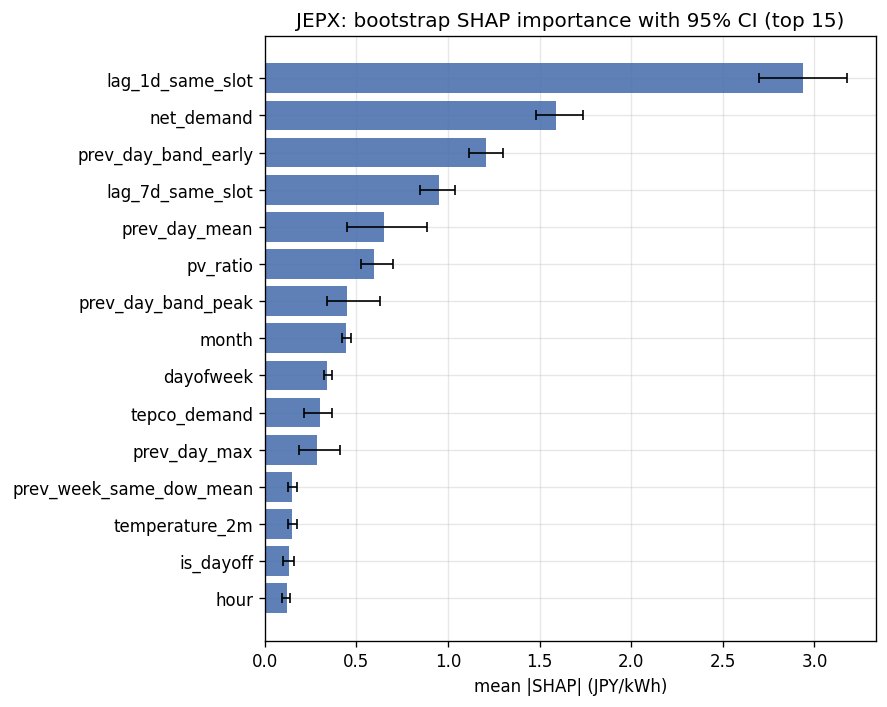

In [7]:
TOP=15
order=list(S.index[:TOP])
hot=lambda c: S.loc[c,"cv"]>1.8*med_cv
col=lambda c: "#d1495b" if hot(c) else "#4c72b0"
# 図: mean|SHAP| + 95%CI
oo=order[::-1]; yv=np.arange(len(oo)); means=S.loc[oo,"mean"].values
err=np.vstack([means-S.loc[oo,"ci_lo"].values, S.loc[oo,"ci_hi"].values-means])
fig,ax=plt.subplots(figsize=(7.5,6))
ax.barh(yv,means,color=[col(c) for c in oo],alpha=.9)
ax.errorbar(means,yv,xerr=err,fmt="none",ecolor="black",capsize=3,lw=1)
ax.set_yticks(yv); ax.set_yticklabels(oo); ax.set_xlabel("mean |SHAP| (JPY/kWh)")
ax.set_title("JEPX: bootstrap SHAP importance with 95%% CI (top %d)"%TOP)
plt.tight_layout(); plt.savefig("img/jepx_bar_ci.png",bbox_inches="tight"); plt.show()

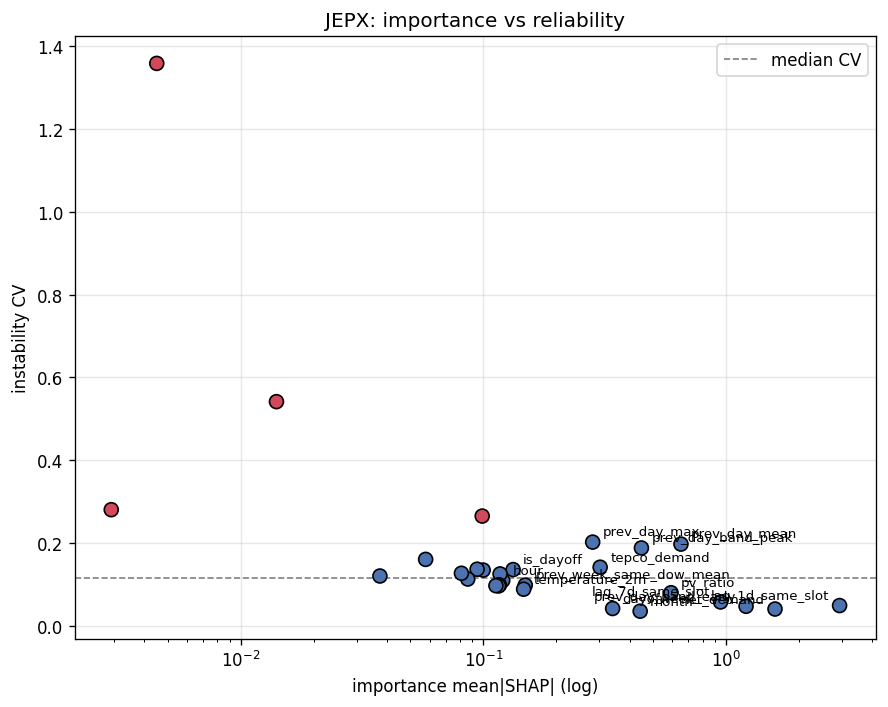

In [8]:
# 図: 重要度 vs CV（右上=高重要・低信頼）
fig,ax=plt.subplots(figsize=(7.5,6))
ax.scatter(S["mean"],S["cv"],c=[col(c) for c in S.index],s=70,edgecolor="k",zorder=3)
top4=set(S.index[:4])
for c in S.index[:TOP]:
    left = c in top4
    ax.annotate(c,(S.loc[c,"mean"],S.loc[c,"cv"]),
                xytext=(-6 if left else 6, 4), textcoords="offset points",
                ha="right" if left else "left", fontsize=8)
ax.axhline(med_cv,ls="--",c="gray",lw=1,label="median CV")
ax.set_xscale("log"); ax.set_xlabel("importance mean|SHAP| (log)"); ax.set_ylabel("instability CV")
ax.set_title("JEPX: importance vs reliability"); ax.legend()
plt.tight_layout(); plt.savefig("img/jepx_scatter.png",bbox_inches="tight"); plt.show()

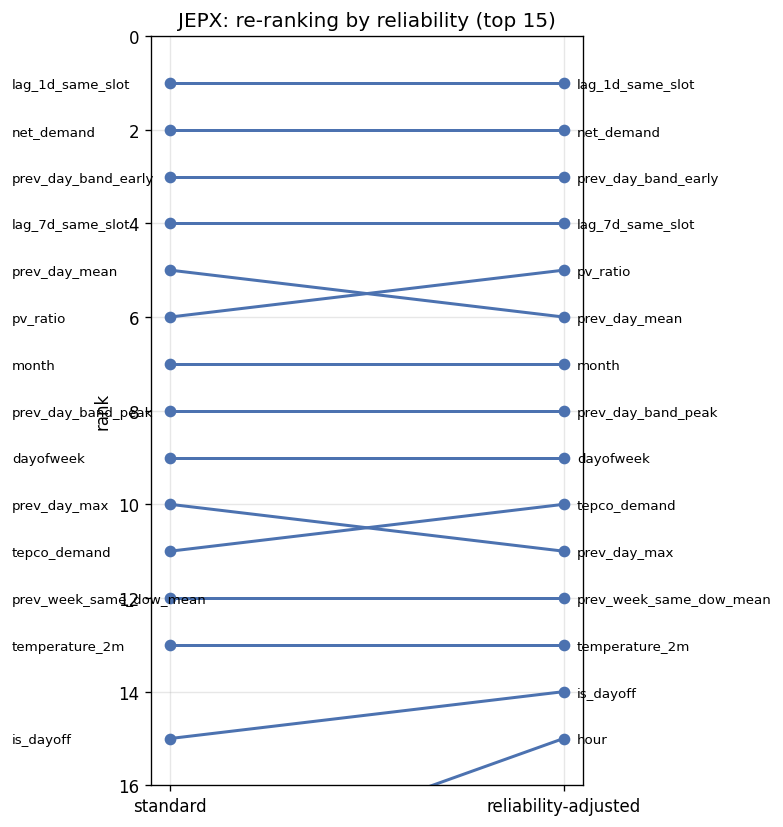

In [9]:
# 図: 再ランキング（top15）
fig,ax=plt.subplots(figsize=(6.5,7))
for c in order:
    ax.plot([0,1],[S.loc[c,"std_rank"],S.loc[c,"adj_rank"]],"-o",color=col(c),lw=1.8,ms=6)
    ax.annotate(c,(0,S.loc[c,"std_rank"]),xytext=(-95,-3),textcoords="offset points",fontsize=8)
    ax.annotate(c,(1,S.loc[c,"adj_rank"]),xytext=(8,-3),textcoords="offset points",fontsize=8)
ax.set_xticks([0,1]); ax.set_xticklabels(["standard","reliability-adjusted"])
ax.set_ylim(TOP+1,0); ax.set_ylabel("rank"); ax.set_title("JEPX: re-ranking by reliability (top %d)"%TOP)
plt.tight_layout(); plt.savefig("img/jepx_rank.png",bbox_inches="tight"); plt.show()
S.to_csv("data/jepx_summary.csv")

## まとめ（JEPX）

- 安定して重要な特徴（前日/前週の同時刻ラグ、`net_demand`）は CV が小さく**信頼できる**。
- スパイク・ピーク検出系（`prev_day_max`, `prev_day_band_peak`, `tepco_demand`, `tepco_solar`）は
  **重要度は高いが CV が高い＝価格スパイクの少数サンプルに依存**しており、再ランキングで順位が下がる。
- 実データでは真の重要度は未知なので「過剰評価」と断定はできないが、
  **信頼度という第2軸を足すことで、棒グラフだけでは見えない依存構造が可視化できる**。